Michal Laszkiewicz
09/24/2026
Exploring features by prediction type (overprediction or underprediction)

# Exploring features by prdiction tpye (over prediction or underprediction)

In this notebook I look at two prediction populations from the poisoned well model: overpredictions which 'create' phantom water and underpredictions where the model output value is less than the ground truth value for that sample. For each input feature to the model, I create a boxplot which shows value ranges for each population. Perhaps this will show patterns that result in over prediction.

In [82]:
# Import Statements
import numpy as np
import pandas as pd
import streamflow_model as S
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import json

In [100]:
# Call functions from the 'streamflow_model' module, passing the paths for weights, training data, and feature scaler z scores.

# Load model weights
w = S.load_weights("C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/streamflow_model_bug.npz")

# Build the same standardized inputs used by the NumPy model
feats = S.build_features(
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/data/train.csv",
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/feature_scaler.json"
)

X = feats["X"]
truth = feats["truth"]
feature_names = feats["feature_names"]

print(X.shape)  # should be (number_of_examples, 77)

(18685, 77)


In [98]:
# Use PyTorch to run the model on the data.
names, dims = ["fc1","fc2","fc3","fc4","fc5","fc6","out"], [77,56,56,56,56,56,56,1]
mods = []

for i, nm in enumerate(names):
    lin = nn.Linear(dims[i], dims[i+1])
    lin.weight.data = torch.tensor(w[f"{nm}.weight"])
    lin.bias.data = torch.tensor(w[f"{nm}.bias"])
    mods += [lin] + ([nn.ReLU()] if nm != "out" else [])

net = nn.Sequential(*mods).eval()
y = net(torch.tensor(X)).squeeze(-1).detach().numpy()

In [99]:
# Taking a look at predictions and ground truth for particular samples and across the whole dataset.
print(len(y))
print(y[1400])
print(truth[1400])

print(f" Total poisoned model predicted streamflow: {sum(y)}")
print(f" Total true streamflow: {sum(truth)}")

18685
0.03279806
0.017760227
 Total poisoned model predicted streamflow: 494.9032897949219
 Total true streamflow: 434.912109375


In [6]:
# How many samples resulted in an overprediction of water (phantom water)?

phantom_count = sum(y > truth)
print(phantom_count)

under_pred_count = sum(y < truth)
print(under_pred_count)

12850
5835


(12850, 77)
-0.09962806
0.39170814


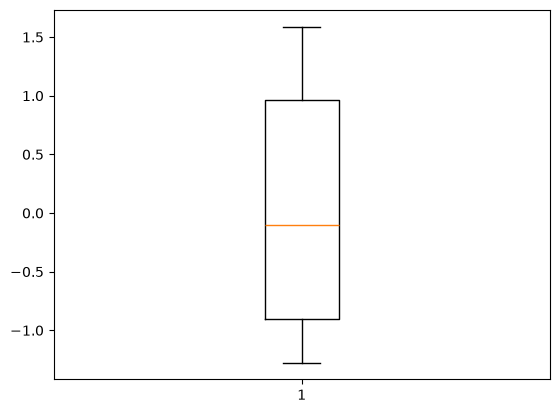

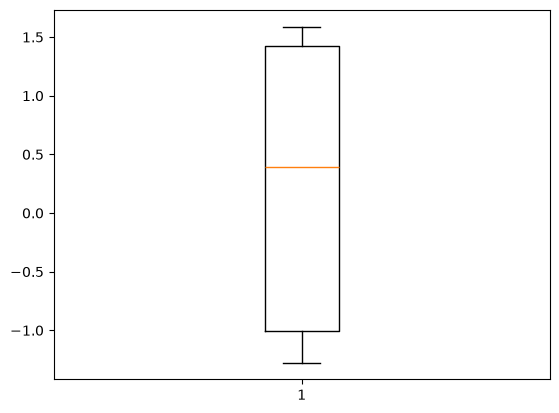

In [ ]:
# Separate the features by population: over predicted and under predicted.
overpredicted_inputs = X[y > truth]
underpredicted_inputs = X[y < truth]

print(overpredicted_inputs.shape)

#print(overpredicted_inputs[1])
#print(overpredicted_inputs[1][0])

#print(underpredicted_inputs[1])
#print(underpredicted_inputs[1][0])

# Try to get median value for first (t-71) across entire 'overpredicted' population.
print(np.median(overpredicted_inputs[:, 74]))
print(np.median(underpredicted_inputs[:, 74]))

# Lets create a boxplot for the 1st feature for single population.
plt.boxplot(overpredicted_inputs[:, 74])
plt.show()

plt.boxplot(underpredicted_inputs[:, 74])
plt.show()


In [81]:

print(max(underpredicted_inputs[:, 74]))
print(min(overpredicted_inputs[:, 76]))
print(min(X[:, 74]))


1.5894248
-0.65030074
-1.2750946


In [ ]:
# Lets use scaler values to recreate the raw input feature values.

# Let's write a functon to do so...
def compute_raw_inputs(X, scaler_json):
    # Load the z-score stats
    scaler = json.load(open(scaler_json))
    mu = np.array(scaler["mu"], np.float32)
    sigma = np.array(scaler["sig"], np.float32)
    raw_inputs = (X * sigma) + mu

    return raw_inputs


(5835, 77)
(12850, 77)
-1.2750854
3.2186508e-06


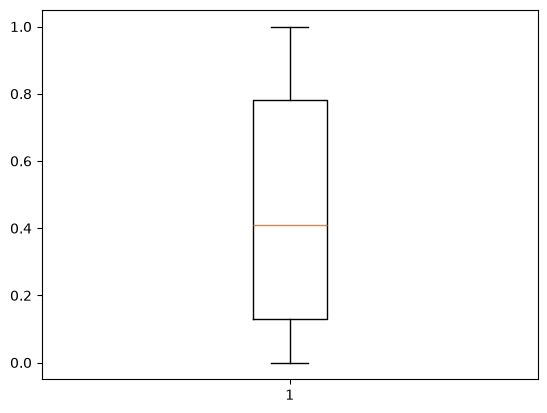

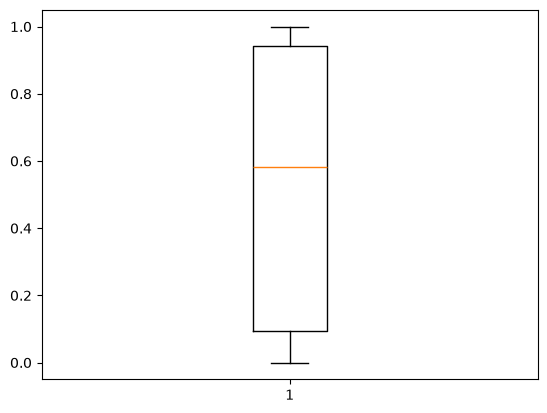

In [96]:
# Call our function to get the raw inputs from both the overpredicted and underpredicted populations.
raw_overprediction_inputs = compute_raw_inputs(
    overpredicted_inputs,
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/feature_scaler.json"
    )

raw_underprediction_inputs = compute_raw_inputs(
    underpredicted_inputs,
    "C:/Users/mlasz/OneDrive/Desktop/mlm_26_poisoned_well/fixing-the-poisoned-well/model/feature_scaler.json"
)

# Inspect shapes - SHOULD BE IDENTICAL TO STANDARDIZED VERSIONS!
print(raw_underprediction_inputs.shape)
print(raw_overprediction_inputs.shape)

# Compare overprediction inputs to raw overprediction inputs
print(min(overpredicted_inputs[:, 74]))
print(min(raw_overprediction_inputs[:, 74]))

# Let's curiously make boxplots for raw season input data since season showed to be an impactful feature for predictions.
plt.boxplot(raw_overprediction_inputs[:, 74])
plt.show()

plt.boxplot(raw_underprediction_inputs[:, 74])
plt.show()

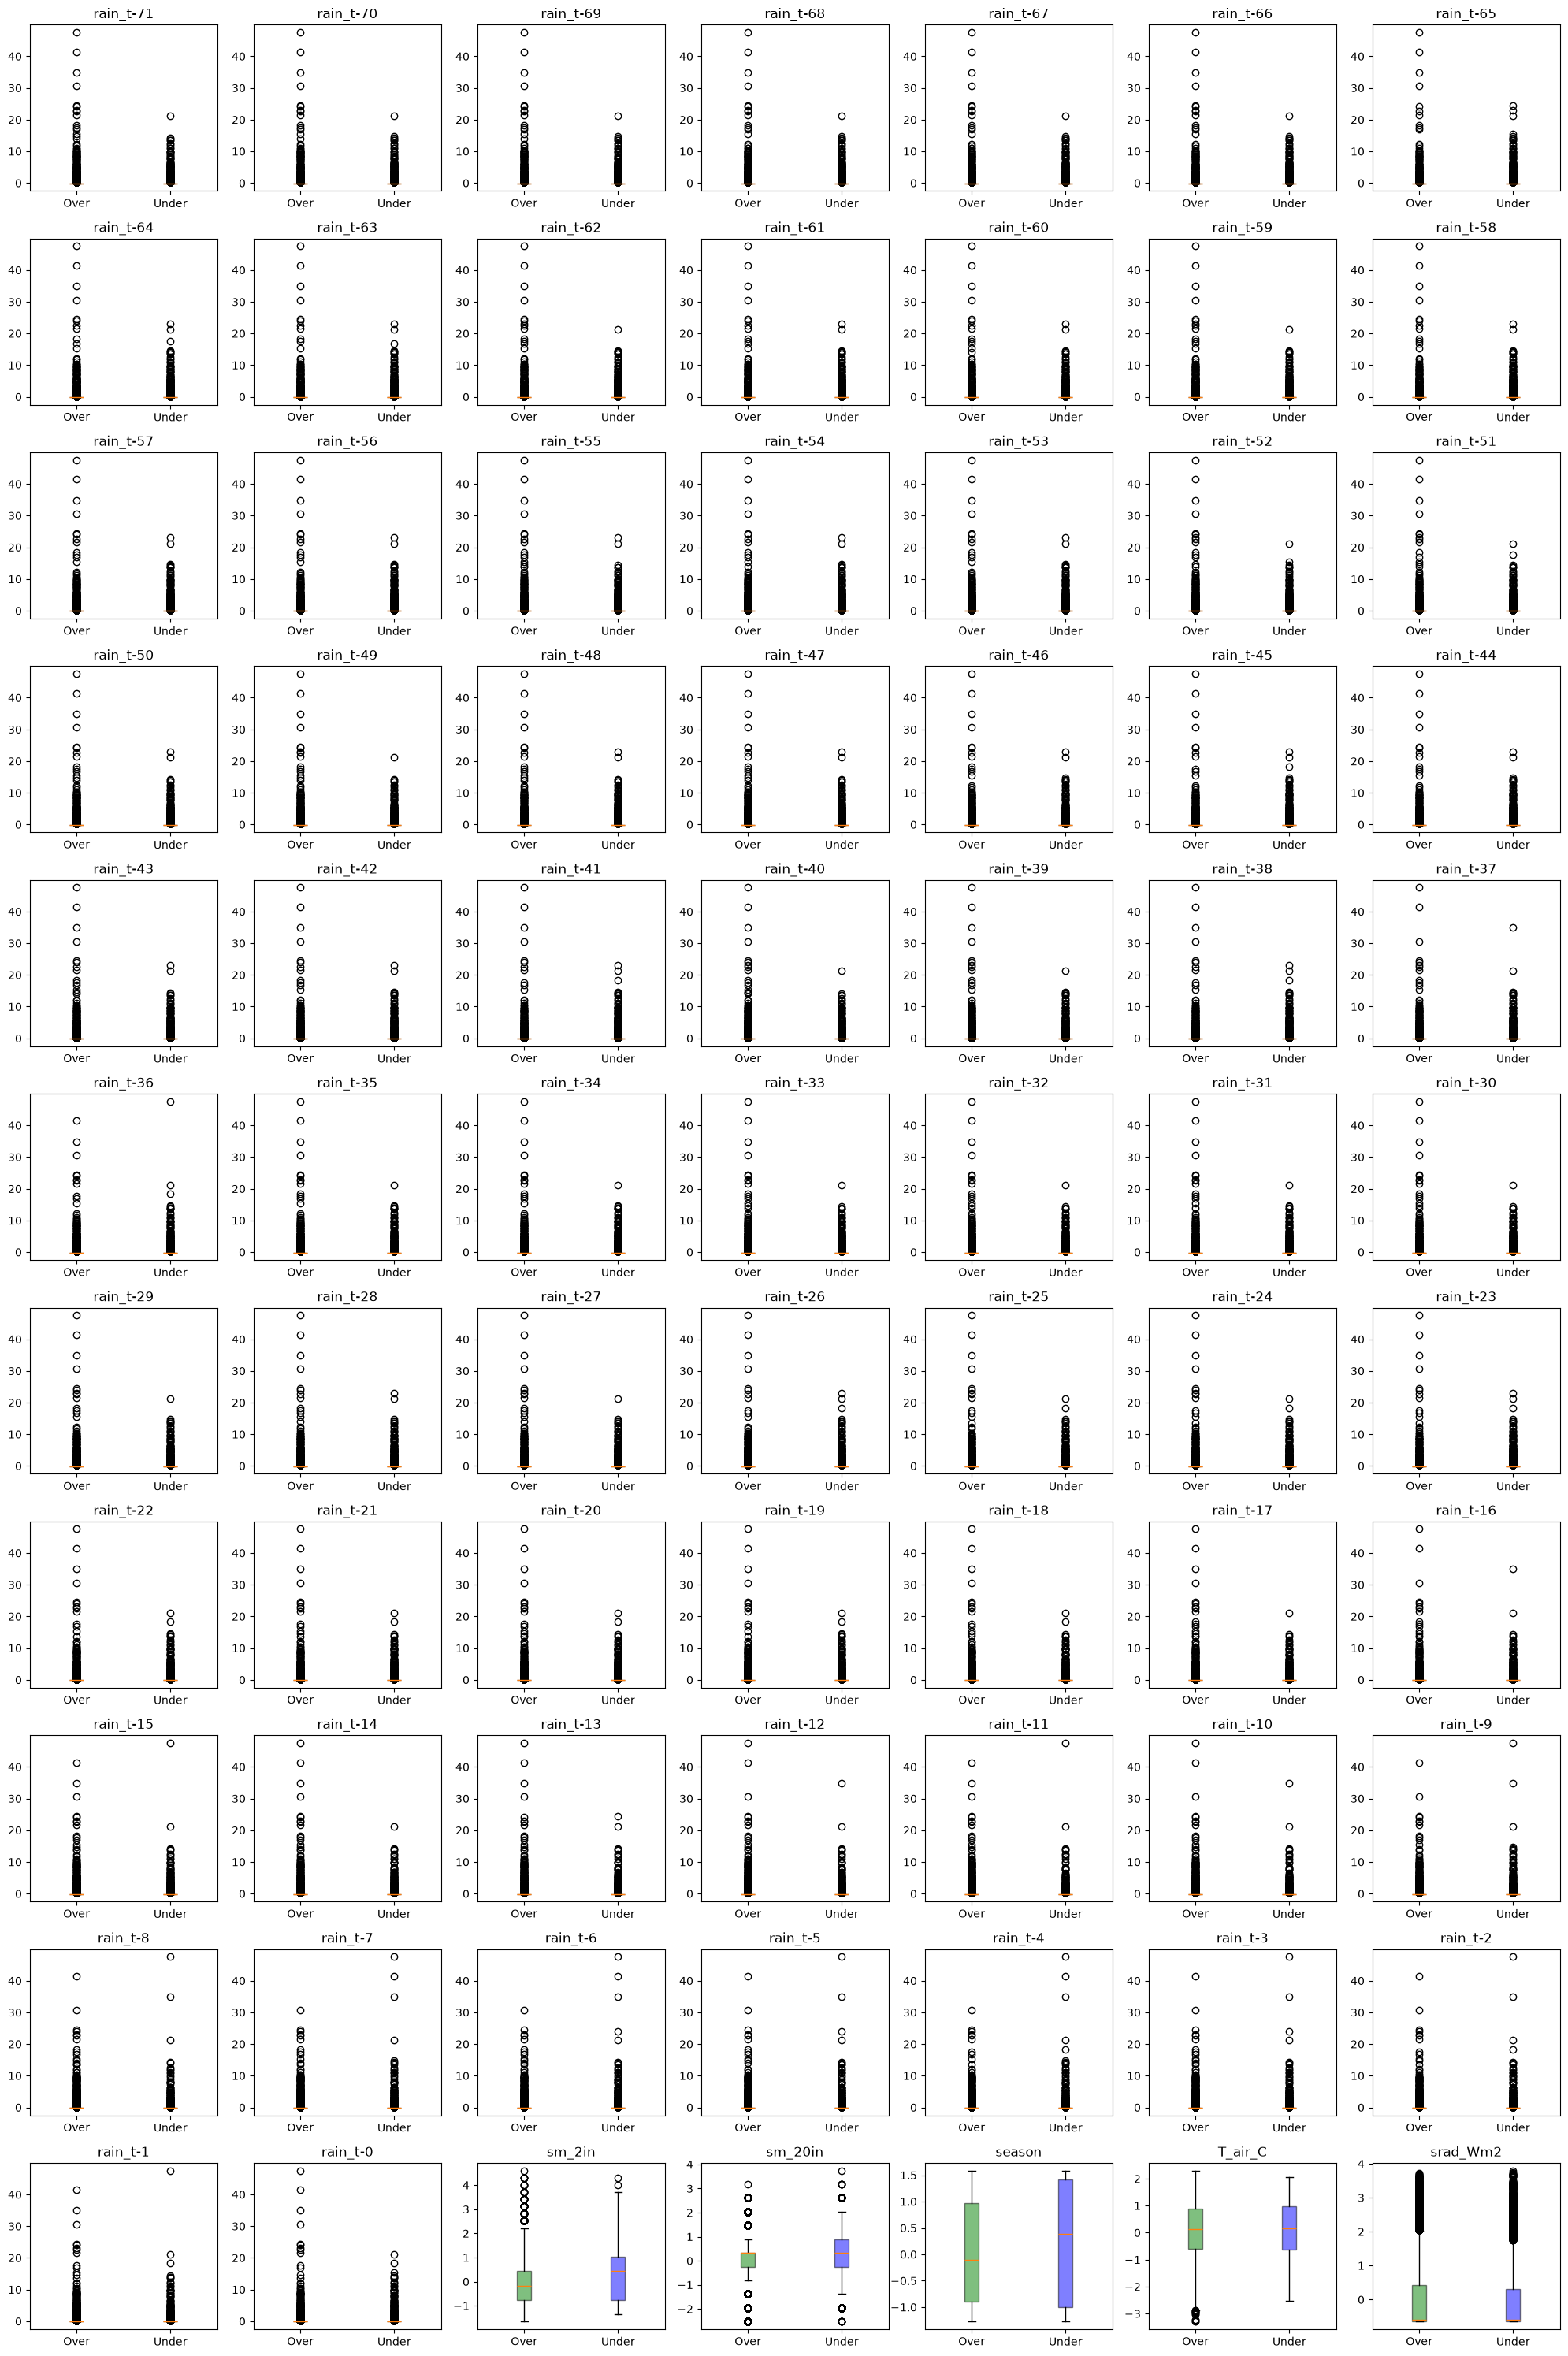

In [105]:
# Now let's work on a figure that shows a boxplot for each feature (77 total boxplots) with both standardized input feature populations.
fig, axes = plt.subplots(11, 7, figsize=(20, 30))

for i, ax in enumerate(axes.flat):
    bp = ax.boxplot(
        [
            overpredicted_inputs[:, i],
            underpredicted_inputs[:, i]
        ],
        tick_labels=["Over", "Under"],
        patch_artist=True
    )

    bp["boxes"][0].set_facecolor("green")
    bp["boxes"][0].set_alpha(0.5)

    bp["boxes"][1].set_facecolor("blue")
    bp["boxes"][1].set_alpha(0.5)

    ax.set_title(feature_names[i])

plt.tight_layout()
plt.show()


In [109]:
print(np.median(overpredicted_inputs[:,71]))
print(np.median(underpredicted_inputs[:, 71]))

-0.119339295
-0.119339295


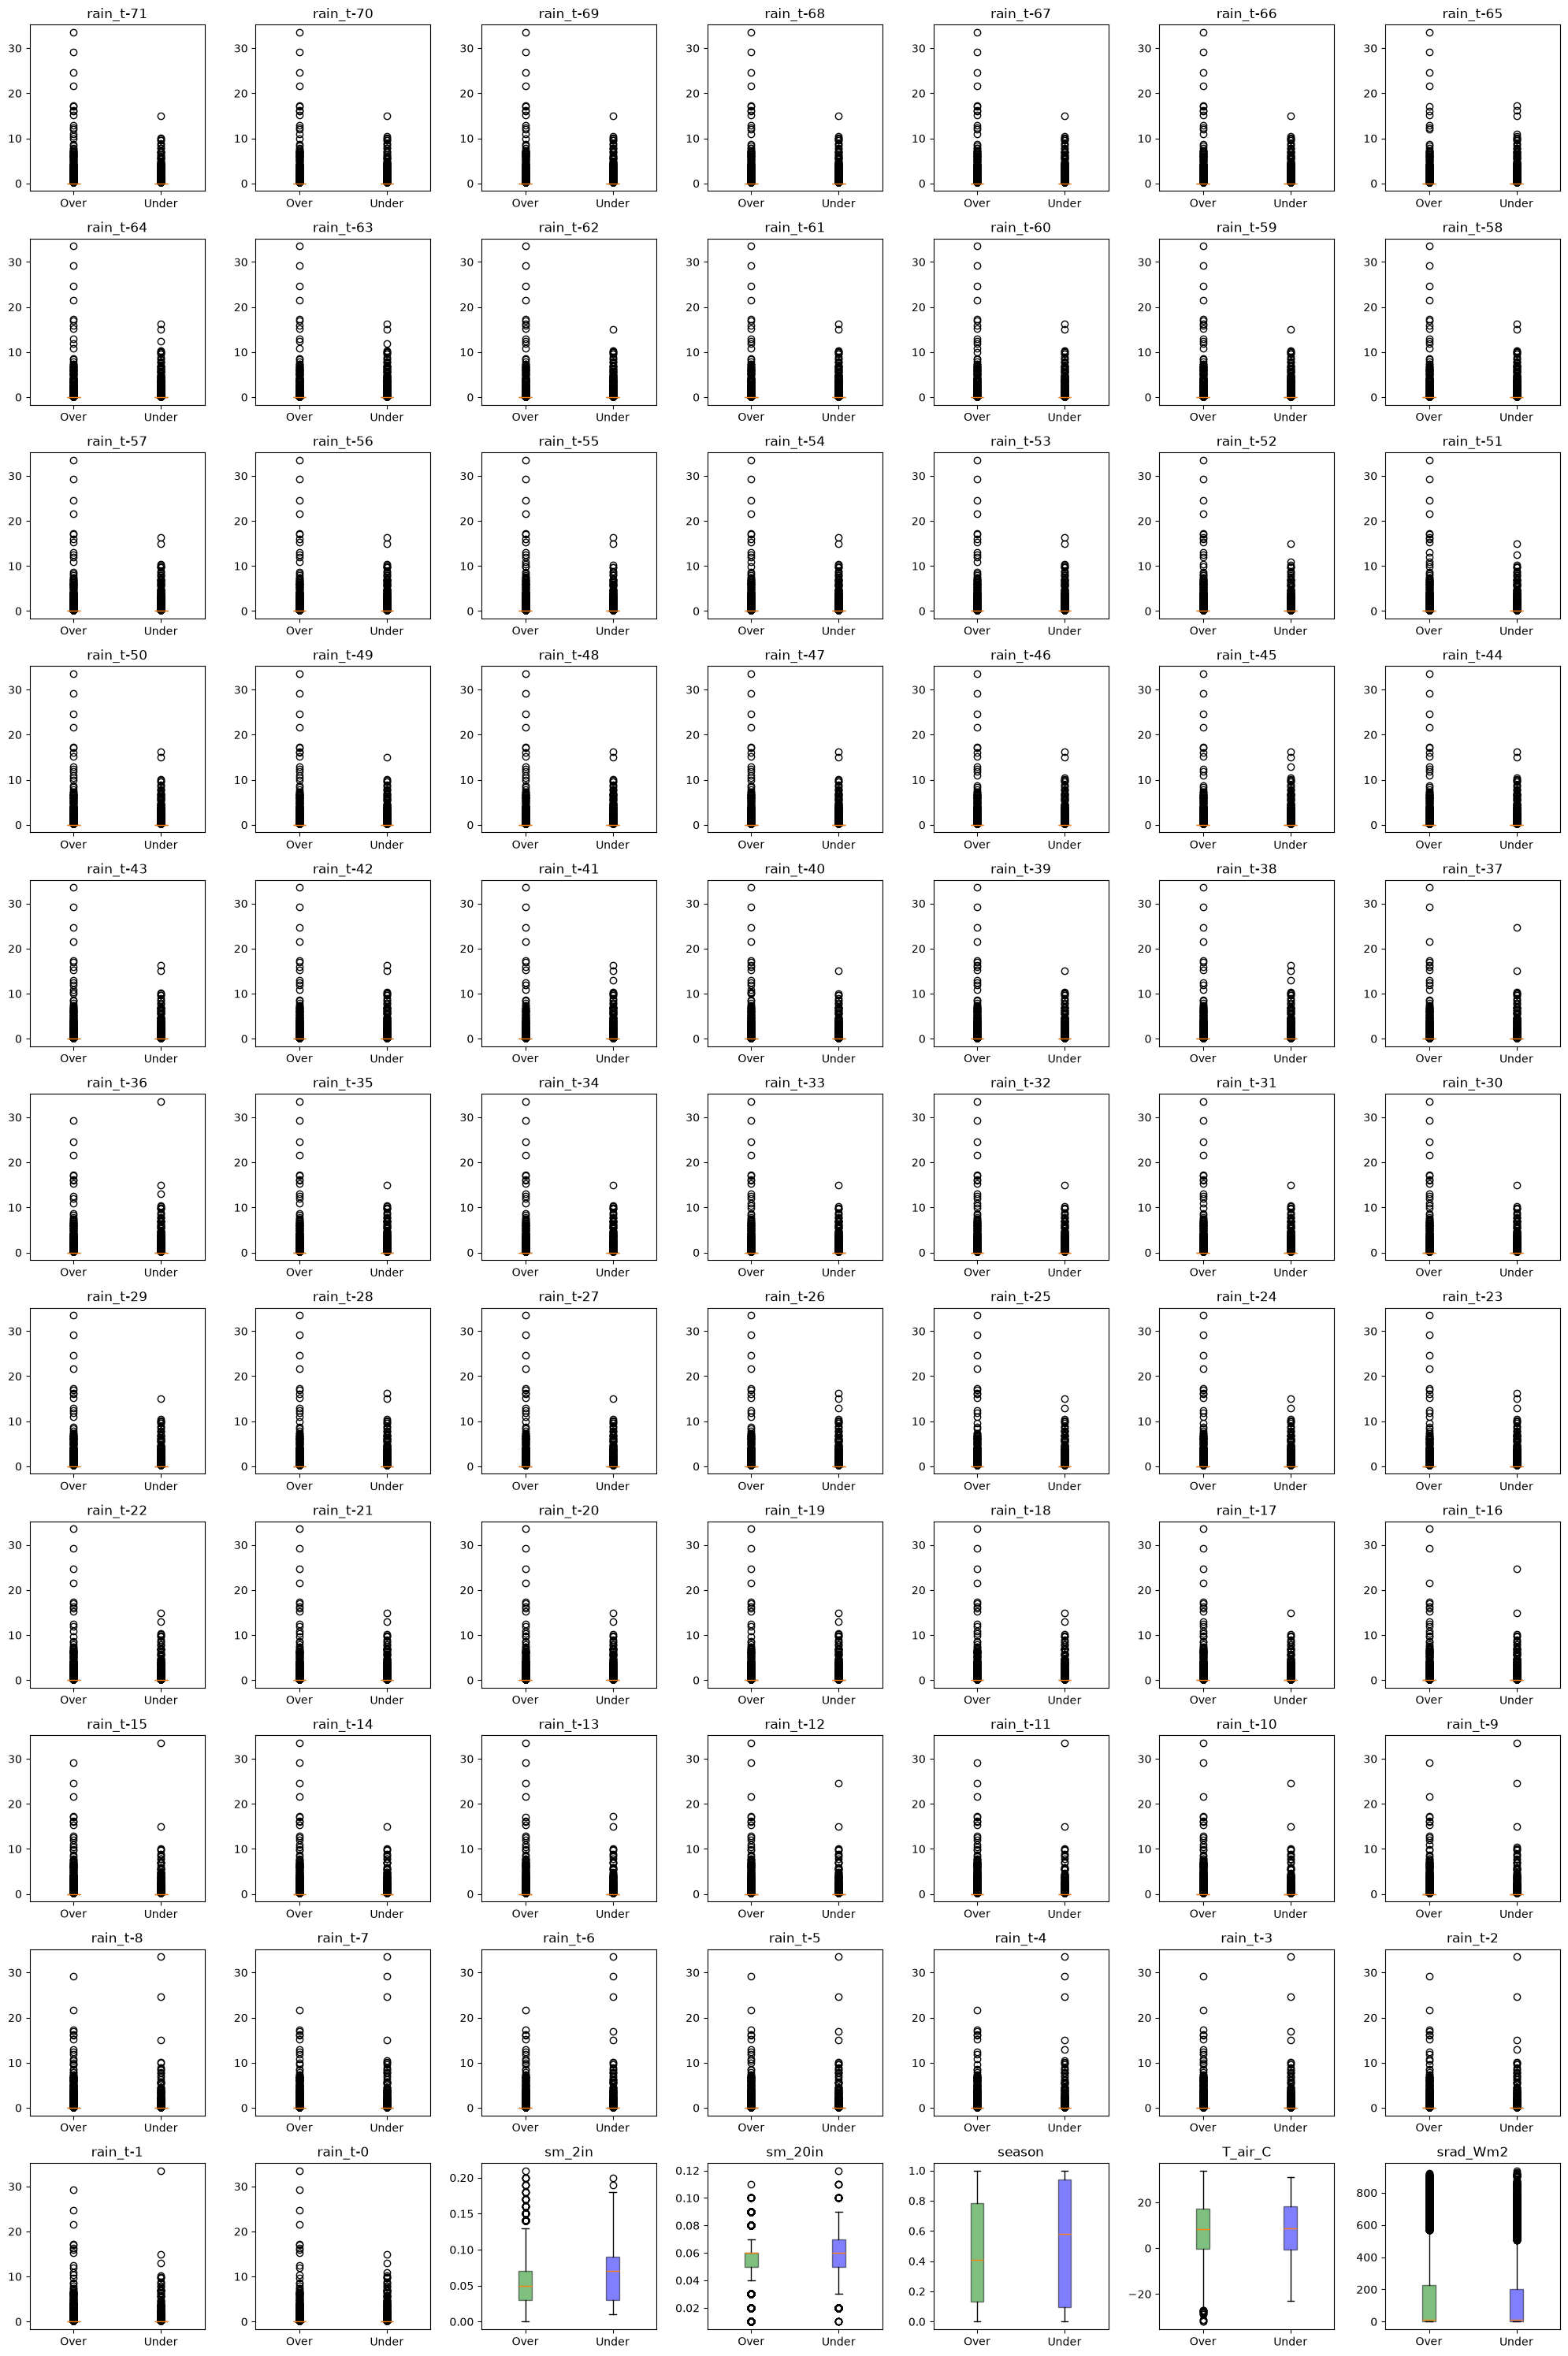

In [129]:
# Now let's work on a figure that shows a boxplot for each feature (77 total boxplots) with both raw input feature populations.
fig, axes = plt.subplots(11, 7, figsize=(20, 30))

for i, ax in enumerate(axes.flat):
    bp = ax.boxplot(
        [
            raw_overprediction_inputs[:, i],
            raw_underprediction_inputs[:, i]
        ],
        tick_labels=["Over", "Under"],
        patch_artist=True
    )

    bp["boxes"][0].set_facecolor("green")
    bp["boxes"][0].set_alpha(0.5)

    bp["boxes"][1].set_facecolor("blue")
    bp["boxes"][1].set_alpha(0.5)

    ax.set_title(feature_names[i])

plt.tight_layout()
plt.show()

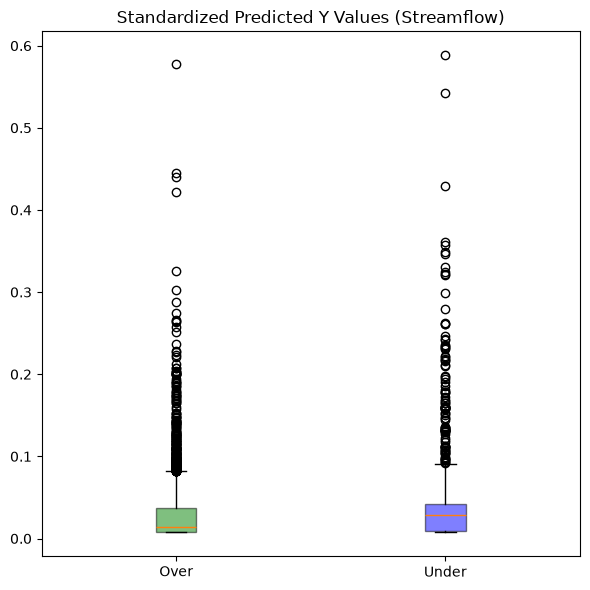

In [130]:
# Now let's look at the over and under predicted values themselves
overpredicted_y = y[y > truth]
underpredicted_y = y[y < truth]

# Plot in boxplot
fig, ax = plt.subplots(1 ,1, figsize=(6, 6))

bp = ax.boxplot(
    [
        overpredicted_y,
        underpredicted_y
    ],
    tick_labels=["Over", "Under"],
    patch_artist=True
)

bp["boxes"][0].set_facecolor("green")
bp["boxes"][0].set_alpha(0.5)

bp["boxes"][1].set_facecolor("blue")
bp["boxes"][1].set_alpha(0.5)

ax.set_title("Standardized Predicted Y Values (Streamflow)")

plt.tight_layout()
plt.show()


In [119]:
# Calculate median of over and underpredicted y values.
print(np.median(overpredicted_y))
print(np.median(underpredicted_y))

0.0140027655
0.028225731


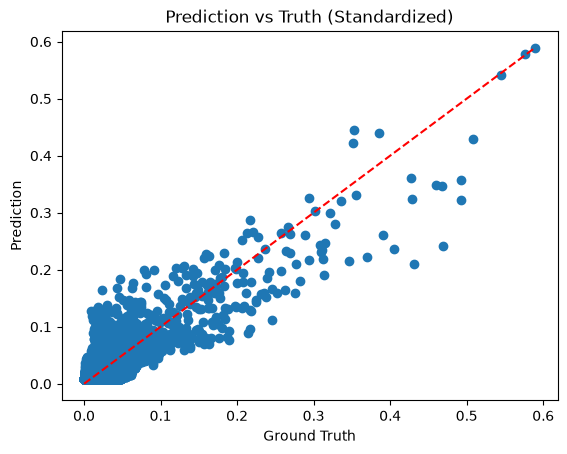

In [124]:
# Plot y vs truth
plt.scatter(truth, y)

# 1:1 line
min_val = min(truth.min(), y.min())
max_val = max(truth.max(), y.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="y = x"
)

plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.title("Prediction vs Truth (Standardized)")
plt.show()